
<font size = "5"> **Day 1: [Atomic Resolution STEM and Machine Learning](../MLSTEM2026.ipynb)** </font>


<hr style="height:1px;border-top:4px solid #FF8200" />

[Download](https://github.com/gduscher/MLSTEM2026/raw/refs/heads/main/Day%201/4PM_Atom_Finding_Hackathon.ipynb)

[![OpenInColab](https://colab.research.google.com/assets/colab-badge.svg)](
   https://colab.research.google.com/github/gduscher/MLSTEM2026/blob/main/Day%201/4PM_Atom_Finding_Hackathon.ipynb)
   
# Atom Finding in STEM: Traditional Methods vs. Neural Networks
part of the workshop of

<font size = "5"> **[Machine Learning in Transmission Electron Microscopy](../MLSTEM2026.ipynb)**</font>


**Day1: Atomic Resolution STEM,**

---
Darel Pates, Gerd Duscher - University of Tennessee, Knoxville

## Overview
This notebook walks through two approaches to finding atoms in HAADF-STEM images:

1. **Traditional**: Blob detection using the Laplacian of Gaussian
2. **Neural network**: A simple U-Net trained on simulated data

We start with a simulated image (where we know the true atom positions) so we can measure how well each method works. Then we apply both to a real image.

## Setup
On Google Colab please change the Runtime Type (in Runtime menu) to GPU first.

In [20]:
!pip install -q torch torchvision scikit-image scipy matplotlib numpy ase

In [21]:
import numpy as np
import matplotlib.pyplot as plt
import scipy

import skimage
import torch

import ase
import ase.visualize.plot

np.random.seed(42)
torch.manual_seed(42)
print("Ready!")

Ready!


## Part 1: Make a simulated HAADF image

We'll create a fake HAADF image by placing Gaussian peaks on a silicon lattice, then adding noise. Because we built it ourselves, we know exactly where every atom is — this gives us ground truth to test against.

First we use Graphite as the hexagonal lattice with the **atomic simulation environment** (ase)

structure matrix 
 [[ 2.46  0.    0.  ]
 [-1.23  2.13  0.  ]
 [ 0.    0.    6.71]]


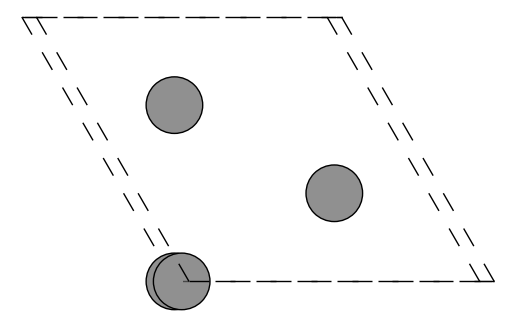

In [36]:
# Create graphite unit cell (or structure matrix)
a = b = 2.46  # Angstrom
c = 6.71  # Angstrom
gamma = 120
alpha = beta = 90

## Create the structure matrix for a hexagonal system explicitly:
structure_matrix = np.array([[a, 0.0, 0.0],  ## also called the structure matrix
                             [np.cos(np.radians(gamma))*a, np.sin(np.radians(gamma))*a, 0.0 ],
                             [0.0, 0.0, c]
                            ])
print('structure matrix \n', np.round(structure_matrix, 3))

elements = ['C']*4
base = [[0, 0, 0], [0, 0, 1/2], [1/3, 2/3, 0], [2/3, 1/3, 1/2]]


crystal = ase.Atoms(elements, cell=structure_matrix, scaled_positions=base)
ase.visualize.plot.plot_atoms(crystal, radii=0.3, rotation=('0x,1y,0z'));

structure matrix 
 [[5.43 0.   0.  ]
 [0.   5.43 0.  ]
 [0.   0.   5.43]]


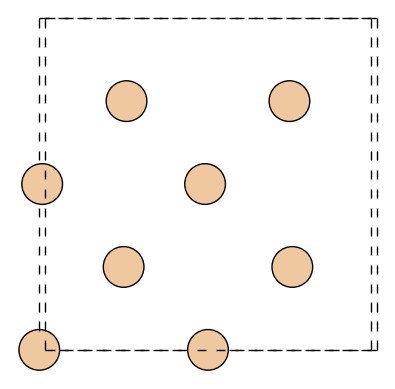

In [22]:

# Create silicon diamond unit cell
a = 5.43  # Angstrom (silicon lattice constant)

## Cubic structure matrix
structure_matrix = np.array([[a, 0.0, 0.0],
                             [0.0, a, 0.0],
                             [0.0, 0.0, a]])
print('structure matrix \n', np.round(structure_matrix, 3))

elements = ['Si']*8
base = [[0, 0, 0], [1/2, 1/2, 0], [1/2, 0, 1/2], [0, 1/2, 1/2],
        [1/4, 1/4, 1/4], [3/4, 3/4, 1/4], [3/4, 1/4, 3/4], [1/4, 3/4, 3/4]]

crystal = ase.Atoms(elements, cell=structure_matrix, scaled_positions=base)
ase.visualize.plot.plot_atoms(crystal, radii=0.3, rotation=('0x,1y,0z'));

Then we add Gaussians to image according to positions.

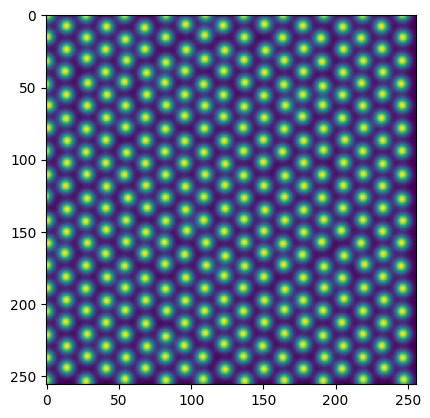

In [38]:
# ------Input ----------
pixel_size = 0.3  # in Angstrom
supercell_number = 15
sigma = 1 # in Angstrom
wobble = 0.05 # in Angstrom
# ----------------------

def get_image(atoms, size=256, pixel_size=.3, sigma=1, wobble=.05):
    image = np.zeros([size, size])
    coords = np.arange(0, size)*pixel_size
    xx, yy = np.meshgrid(coords, coords)
    ## Simplification of crystal is here: add atomic number dependence to crystal slap
    positions = np.unique(atoms.get_positions()[:, :2], axis=0)/pixel_size
    rim_max = (size+3)*pixel_size
    rim_min = -2*pixel_size
    atom_positions = []
    for (x,y)in positions:
        dx, dy = np.random.normal(0, wobble, 2)/pixel_size
        xdx = x + dx
        ydy = y + dy
        if rim_min < x <rim_max and rim_min < y <rim_max :
            image += np.exp(-(((xx - xdx) ** 2 + (yy - ydy) ** 2) / (2 * sigma**2)))
            atom_positions.append([xdx,ydy])
    return image, np.array(atom_positions)/pixel_size

image, atom_positions = get_image(crystal*supercell_number, size=256,
                                  pixel_size=pixel_size, sigma=sigma, wobble=wobble)
plt.figure()
plt.imshow(image)

Add Poission noise to image

The noise is dependent on the count level (number of electrons)

Text(0.5, 0, 'distance (A)')

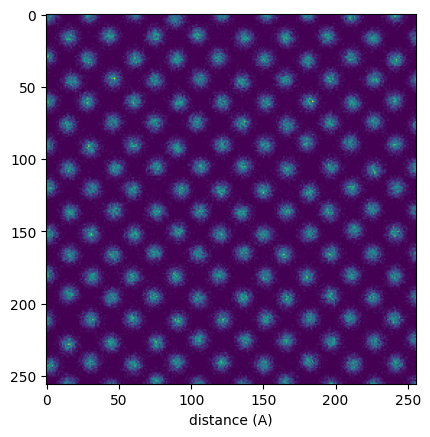

In [35]:
# ------Input ----------
counts = 2000000
# ----------------------
def poisson_noise(image: np.ndarray, counts: float) -> np.ndarray:
        """Apply normalized Poisson noise based on simulated electron counts."""
        image = image - image.min()
        total = float(image.sum())
        if total <= 0 or counts <= 0:
            return np.zeros_like(image, dtype=np.float32)
        image = image / total
        noisy = np.random.poisson(image * counts).astype(np.float32)
        noisy -= noisy.min()
        m = float(noisy.max())
        if m > 0:
            noisy /= m
        return noisy
pixel_size=.3
plt.figure()
plt.imshow(poisson_noise(image, counts))#, extent=np.array([0, image.shape[0], image.shape[0],0])*pixel_size)
# plt.scatter(atom_positions[:,0], atom_positions[:,1], c='red', alpha =.5)
plt.xlabel("distance (A)")

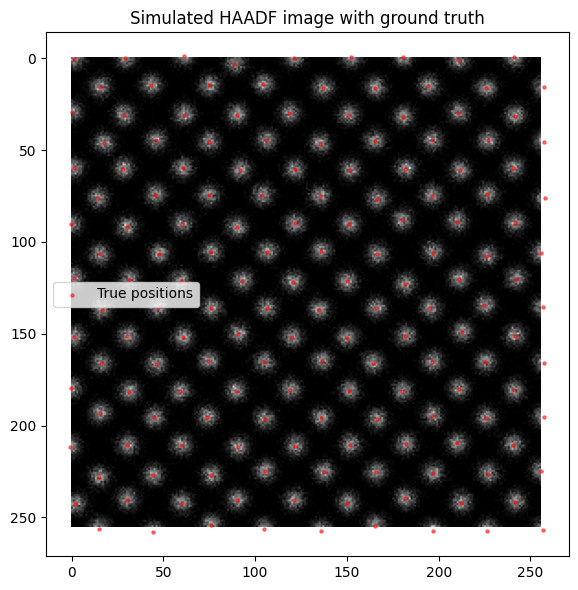

In [33]:
def simulate_haadf(atoms, size=256, wobble=0.08, counts=200000, sigma=1):
    """Create a simulated HAADF image with atoms on a silicon lattice."""
    image, atom_positions = get_image(atoms, wobble=wobble, sigma=sigma)
    noisy_image =poisson_noise(image, counts)

    return image, noisy_image, atom_positions

_, image, true_atoms = simulate_haadf(crystal*supercell_number, counts=counts)


fig, ax = plt.subplots(1, 1, figsize=(6, 6))
ax.imshow(image, cmap='gray')
ax.scatter(true_atoms[:, 0], true_atoms[:, 1], c='red', s=5, alpha=0.5, label='True positions')
ax.legend()
ax.set_title('Simulated HAADF image with ground truth')
plt.tight_layout()
plt.show()

## Part 2: Traditional blob detection

The Laplacian of Gaussian (LoG) convolves the image at multiple scales with a kernel formed by taking the second spatial derivative of a 2D Gaussian, which highlights regions brighter than their immediate surroundings. Where the response is strong, there's a blob — an atom.

**Try changing** `threshold` and `max_sigma` to see how they affect detection.

Found 161 atoms (true: 162)


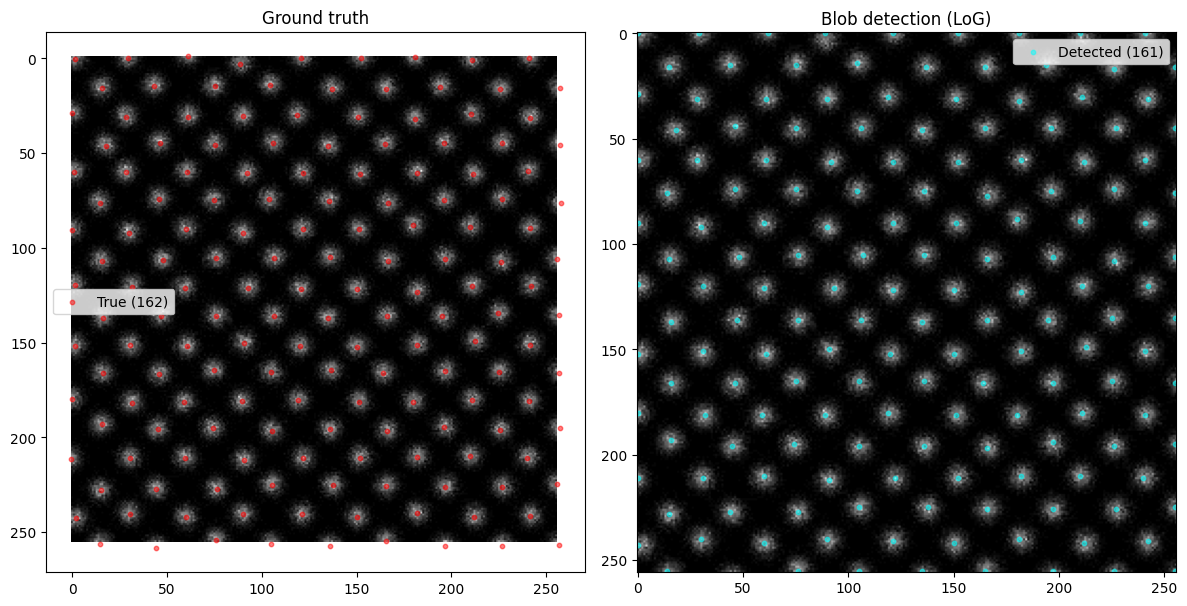

In [34]:
# --- Parameters you can play with ---
threshold = 0.17
max_sigma = 5
# ------------------------------------

blobs = skimage.feature.blob_log(image, max_sigma=max_sigma, threshold=threshold)
blob_positions = blobs[:, :2]  # (y, x) format from skimage

print(f"Found {len(blob_positions)} atoms (true: {len(true_atoms)})")

fig, axes = plt.subplots(1, 2, figsize=(12, 6))

axes[0].imshow(image, cmap='gray')
axes[0].scatter(true_atoms[:, 0], true_atoms[:, 1], c='red', s=10, alpha=0.5, label=f'True ({len(true_atoms)})')
axes[0].set_title('Ground truth')
axes[0].legend()

axes[1].imshow(image, cmap='gray')
# blob_log returns (row, col) = (y, x), so swap for scatter
axes[1].scatter(blob_positions[:, 1], blob_positions[:, 0], c='cyan', s=10, alpha=0.5, label=f'Detected ({len(blob_positions)})')
axes[1].set_title('Blob detection (LoG)')
axes[1].legend()

plt.tight_layout()
plt.show()

## Part 3: Build a simple neural network

Now we'll try a neural network approach. A neural network is an encoder-decoder architecture:
- The **encoder** (downsampling path) compresses the image to learn what atoms look like
- The **decoder** (upsampling path) reconstructs a full-resolution map of where atoms are
- **Skip connections** between encoder and decoder preserve spatial detail

Our neural network takes an image in, and outputs a probability map where bright pixels = likely atom locations.

In [ ]:
class TinyUNet(torch.nn.Module):
    """A minimal U-Net for atom segmentation."""

    def __init__(self):
        super().__init__()
        # Encoder (downsampling)
        self.enc1 = self._block(1, 16)
        self.enc2 = self._block(16, 32)
        self.pool = torch.nn.MaxPool2d(2)

        # Bottleneck
        self.bottleneck = self._block(32, 64)

        # Decoder (upsampling)
        self.up2 = torch.nn.ConvTranspose2d(64, 32, kernel_size=2, stride=2)
        self.dec2 = self._block(64, 32)  # 64 because of skip connection
        self.up1 = torch.nn.ConvTranspose2d(32, 16, kernel_size=2, stride=2)
        self.dec1 = self._block(32, 16)  # 32 because of skip connection

        # Output: single channel probability map
        self.out = torch.nn.Conv2d(16, 1, kernel_size=1)

    def _block(self, in_ch, out_ch):
        return torch.nn.Sequential(
            torch.nn.Conv2d(in_ch, out_ch, 3, padding=1),
            torch.nn.BatchNorm2d(out_ch),
            torch.nn.ReLU(inplace=True),
            torch.nn.Conv2d(out_ch, out_ch, 3, padding=1),
            torch.nn.BatchNorm2d(out_ch),
            torch.nn.ReLU(inplace=True),
        )

    def forward(self, x):
        # Encoder
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool(e1))

        # Bottleneck
        b = self.bottleneck(self.pool(e2))

        # Decoder with skip connections
        d2 = self.dec2(torch.cat([self.up2(b), e2], dim=1))
        d1 = self.dec1(torch.cat([self.up1(d2), e1], dim=1))

        return torch.sigmoid(self.out(d1))

model = TinyUNet()
total_params = sum(p.numel() for p in model.parameters())
print(f"Model has {total_params:,} parameters")

Model has 117,393 parameters


## Part 4: Create training data

We generate several simulated images with different noise levels, spacings, and atom displacements. For each image, the **label** is a binary mask with small dots at each atom position — this is what we're training the network to predict.

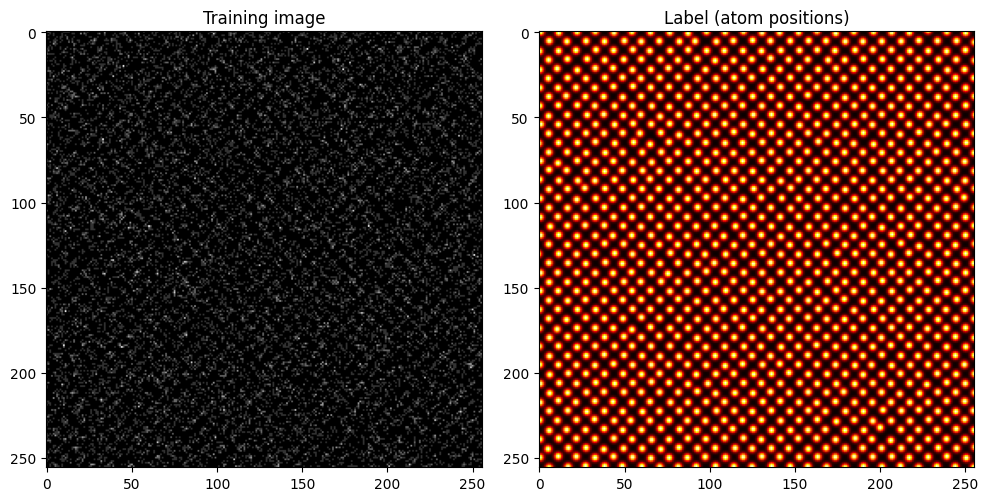

Training set: 20 images


In [ ]:
def make_label_mask(atoms, size=256, sigma=1.5):
    """Create a binary-ish mask with Gaussian dots at each atom position."""
    mask = np.zeros((size, size), dtype=np.float32)
    for ax, ay in atoms:
        yy, xx = np.mgrid[0:size, 0:size]
        mask += np.exp(-((xx - ax)**2 + (yy - ay)**2) / (2 * sigma**2))
    return np.clip(mask, 0, 1)

# Generate training set
n_train = 20
train_images = []
train_labels = []

for i in range(n_train):
    # _, img, atom_positions = simulate_haadf(atomssize=256, spacing=spacing, noise_level=noise, sigma=sigma)
    _, img, atom_positions = simulate_haadf(crystal*supercell_number, counts=counts)
    label = make_label_mask(atom_positions, size=256, sigma=1.5)
    train_images.append(img)
    train_labels.append(label)

train_images = np.array(train_images)
train_labels = np.array(train_labels)

# Show an example
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(train_images[0], cmap='gray')
axes[0].set_title('Training image')
axes[1].imshow(train_labels[0], cmap='hot')
axes[1].set_title('Label (atom positions)')
plt.tight_layout()
plt.show()

print(f"Training set: {n_train} images")

## Part 5: Train the neural network

We train the network to predict atom location maps from noisy images. The loss function is the binary cross-entropy — it penalizes the network when it predicts an atom where there isn't one, or misses one that's there.  You can repeat the training to decrease loss.

**This should take 1–2 minutes on CPU.**

Closer to 20 seconds on Google Colab with GPU

Epoch 10/150, Loss: 0.5802
Epoch 20/150, Loss: 0.5222
Epoch 30/150, Loss: 0.4940
Epoch 40/150, Loss: 0.4739
Epoch 50/150, Loss: 0.4589
Epoch 60/150, Loss: 0.4471
Epoch 70/150, Loss: 0.4377
Epoch 80/150, Loss: 0.4300
Epoch 90/150, Loss: 0.4235
Epoch 100/150, Loss: 0.4180
Epoch 110/150, Loss: 0.4133
Epoch 120/150, Loss: 0.4092
Epoch 130/150, Loss: 0.4071
Epoch 140/150, Loss: 0.4028
Epoch 150/150, Loss: 0.4005


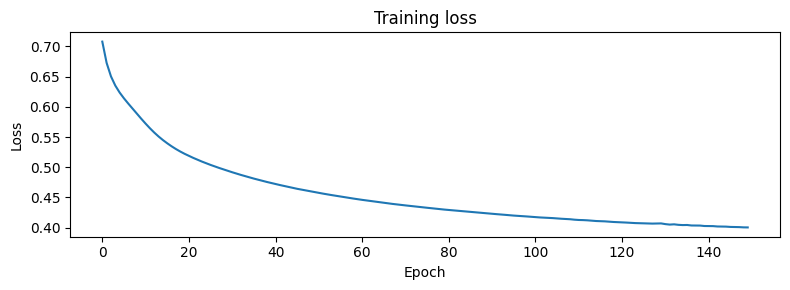

In [ ]:
# -------- Input ----------
epochs = 50
# -------------------------

# Convert to PyTorch tensors
X_train = torch.tensor(train_images[:, None, :, :])  # add channel dim: (N, 1, 256, 256)
y_train = torch.tensor(train_labels[:, None, :, :])

# Training setup
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = TinyUNet().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
criterion = torch.nn.BCELoss()

# Training loop

losses = []

for epoch in range(epochs):
    model.train()
    # simple full-batch training (dataset is small)
    inputs = X_train.to(device)
    targets = y_train.to(device)

    optimizer.zero_grad()
    outputs = model(inputs)
    loss = criterion(outputs, targets)
    loss.backward()
    optimizer.step()

    losses.append(loss.item())
    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1}/{epochs}, Loss: {loss.item():.4f}")

plt.figure(figsize=(8, 3))
plt.plot(losses)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training loss')
plt.tight_layout()
plt.show()

## Part 6: Test the neural network
Now we apply the trained network to our original test image — the one we made in Part 1. We threshold the output probability map to get discrete atom positions.

U-Net found 1152 atoms (true: 1152)


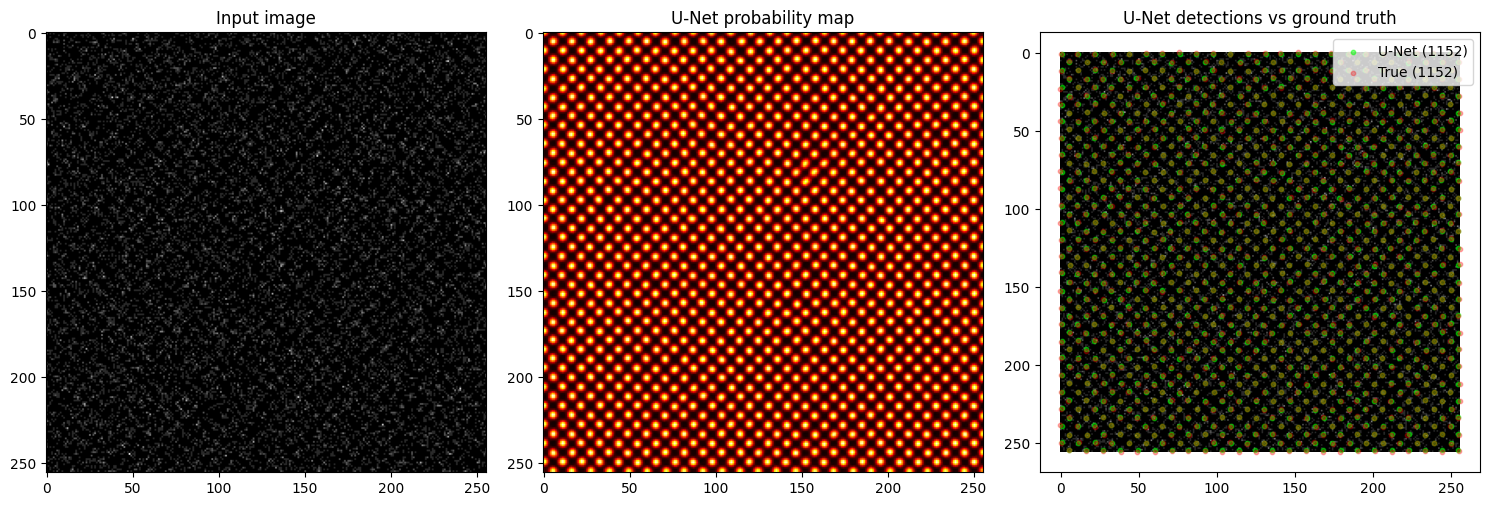

In [ ]:
# Run the test image through the network
model.eval()
with torch.no_grad():
    test_input = torch.tensor(image[None, None, :, :]).to(device)
    prediction = model(test_input).cpu().numpy()[0, 0]

# Find atom positions from the probability map
from scipy.ndimage import label, center_of_mass

binary = prediction > 0.5
labeled, n_atoms = label(binary)
unet_positions = np.array(center_of_mass(binary, labeled, range(1, n_atoms + 1)))

print(f"U-Net found {len(unet_positions)} atoms (true: {len(true_atoms)})")

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(image, cmap='gray')
axes[0].set_title('Input image')

axes[1].imshow(prediction, cmap='hot')
axes[1].set_title('U-Net probability map')

axes[2].imshow(image, cmap='gray')
axes[2].scatter(unet_positions[:, 1], unet_positions[:, 0], c='lime', s=10, alpha=0.5, label=f'U-Net ({len(unet_positions)})')
axes[2].scatter(true_atoms[:, 0], true_atoms[:, 1], c='red', s=10, alpha=0.3, label=f'True ({len(true_atoms)})')
axes[2].legend()
axes[2].set_title('U-Net detections vs ground truth')

plt.tight_layout()
plt.show()

## Part 7: Compare the two methods

Let's put blob detection and U-Net side by side and measure how close each method's detected positions are to the true atom positions.

In [ ]:

def evaluate_detections(detected, true_atoms, tolerance=3.0):
    """Match detected atoms to true atoms and report precision, recall."""
    if len(detected) == 0:
        return 0, 0, 0

    # detected is (y, x), true_atoms is (x, y) — match coordinate systems
    tree = scipy.spatial.cKDTree(true_atoms)
    distances, indices = tree.query(detected[:, ::-1])  # flip detected to (x, y)

    matched = distances < tolerance
    true_positives = matched.sum()
    precision = true_positives / len(detected)
    recall = true_positives / len(true_atoms)
    mean_error = distances[matched].mean() if matched.any() else float('inf')

    return precision, recall, mean_error

blob_p, blob_r, blob_err = evaluate_detections(blob_positions, true_atoms)
unet_p, unet_r, unet_err = evaluate_detections(unet_positions, true_atoms)

print(f"{'Method':<15} {'Precision':>10} {'Recall':>10} {'Mean error (px)':>16}")
print("-" * 53)
print(f"{'Blob (LoG)':<15} {blob_p:>10.2%} {blob_r:>10.2%} {blob_err:>16.2f}")
print(f"{'U-Net':<15} {unet_p:>10.2%} {unet_r:>10.2%} {unet_err:>16.2f}")

Method           Precision     Recall  Mean error (px)
-----------------------------------------------------
Blob (LoG)          97.78%     11.46%             1.22
U-Net              100.00%    100.00%             0.45


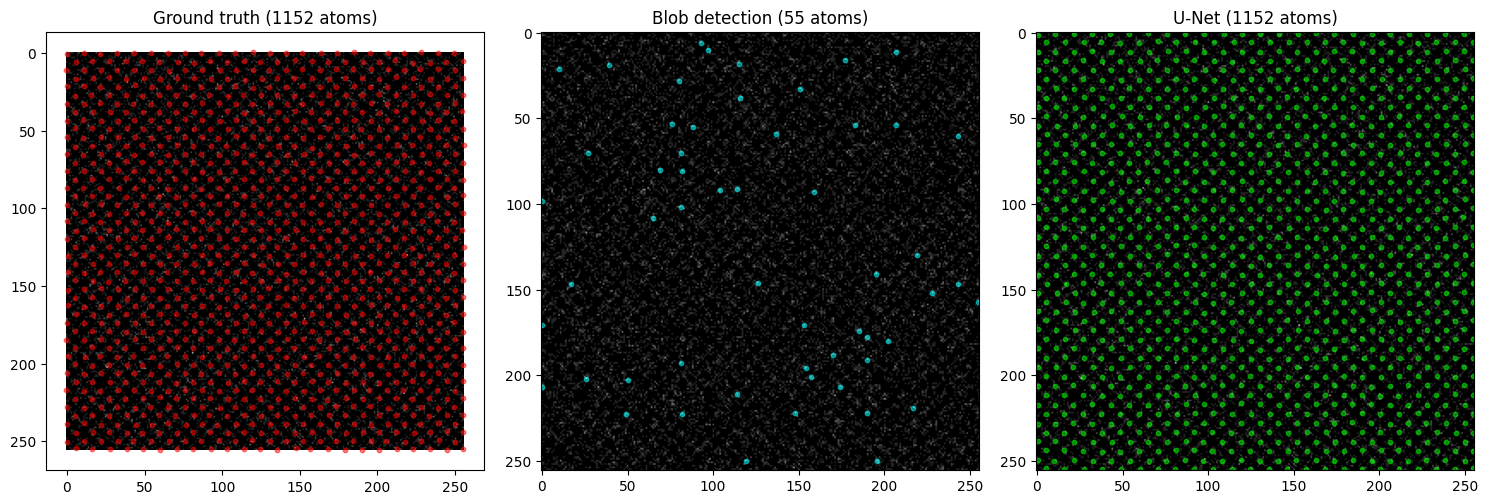

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(image, cmap='gray')
axes[0].scatter(true_atoms[:, 0], true_atoms[:, 1], c='red', s=10, alpha=0.5)
axes[0].set_title(f'Ground truth ({len(true_atoms)} atoms)')

axes[1].imshow(image, cmap='gray')
axes[1].scatter(blob_positions[:, 1], blob_positions[:, 0], c='cyan', s=10, alpha=0.5)
axes[1].set_title(f'Blob detection ({len(blob_positions)} atoms)')

axes[2].imshow(image, cmap='gray')
axes[2].scatter(unet_positions[:, 1], unet_positions[:, 0], c='lime', s=10, alpha=0.5)
axes[2].set_title(f'U-Net ({len(unet_positions)} atoms)')

plt.tight_layout()
plt.show()

## Things to try

- **Increase noise**: Go back to Part 1 and set `counts` to a lower value. Re-run the blob detection and U-Net. Which method degrades more gracefully?
- **Change the threshold**: In Part 2, try different `threshold` values. How sensitive is blob detection to this parameter?
- **Change training images**: In Part 4, change `n_train` to 5 or 50. How much training data does the U-Net need?
- **Harder images**: Try reducing `pixel_size` to .2, so atoms are closer together. Where does each method start to fail?
- **Less Disortion**: Try if less distortion improve the atom finding with the neural network.


## Part 8 (Optional): Apply to a real HAADF image

Now let's load a real .emd file (Velox format) and run both methods on it. EMD files are just HDF5 containers — we extract the image data and normalize it.

**Upload your .emd file to Colab or set the path below.**

In [ ]:
!pip install -q h5py

Image shape: (1024, 1024)


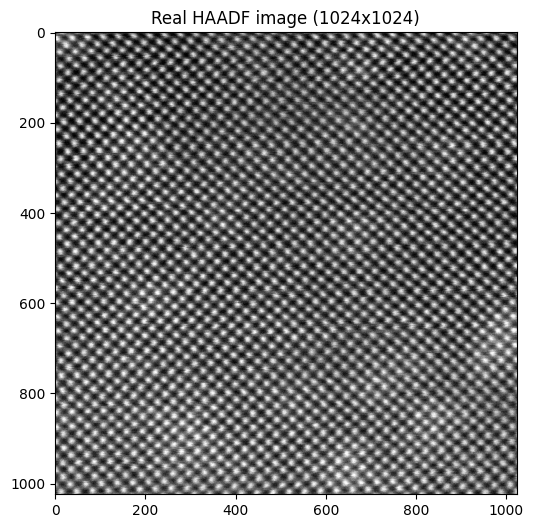

In [ ]:
import h5py

def load_emd(path):
    """Load a HAADF image from a Velox .emd file."""
    with h5py.File(path, "r") as f:
        # Find the first image dataset
        image_group = list(f["Data/Image"].keys())[0]
        data = np.array(f[f"Data/Image/{image_group}/Data"])
    image = np.squeeze(data).astype(np.float32)
    # Percentile normalize to [0, 1]
    lo, hi = np.percentile(image, [1, 99.5])
    image = np.clip((image - lo) / (hi - lo), 0, 1)
    return image

# --- Set your file path here ---
emd_path = "/0109 - Nano STEM HAADF Diffraction.emd"
# --------------------------------

real_image = load_emd(emd_path)
print(f"Image shape: {real_image.shape}")

plt.figure(figsize=(6, 6))
plt.imshow(real_image, cmap='gray')
plt.title(f"Real HAADF image ({real_image.shape[0]}x{real_image.shape[1]})")
plt.show()

### Blob detection on real image

Blob detection found 16649 atoms


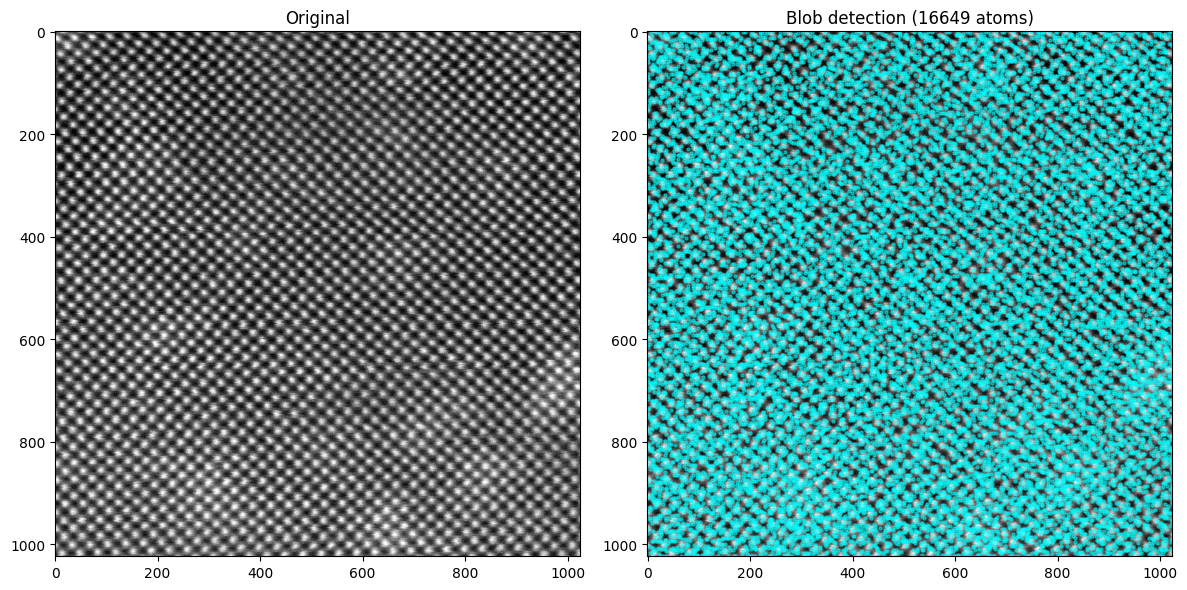

In [ ]:
# You may need to adjust these for your image
threshold = 0.05
max_sigma = 8

real_blobs = skimage.feature.blob_log(real_image, max_sigma=max_sigma, threshold=threshold)
print(f"Blob detection found {len(real_blobs)} atoms")

fig, axes = plt.subplots(1, 2, figsize=(12, 6))
axes[0].imshow(real_image, cmap='gray')
axes[0].set_title('Original')
axes[1].imshow(real_image, cmap='gray')
axes[1].scatter(real_blobs[:, 1], real_blobs[:, 0], c='cyan', s=5, alpha=0.5)
axes[1].set_title(f'Blob detection ({len(real_blobs)} atoms)')
plt.tight_layout()
plt.show()

### U-Net on real image

The U-Net was trained on 256x256 simulated images. Real images are usually larger, so we tile the image into overlapping patches, run the network on each patch, and stitch the results back together.

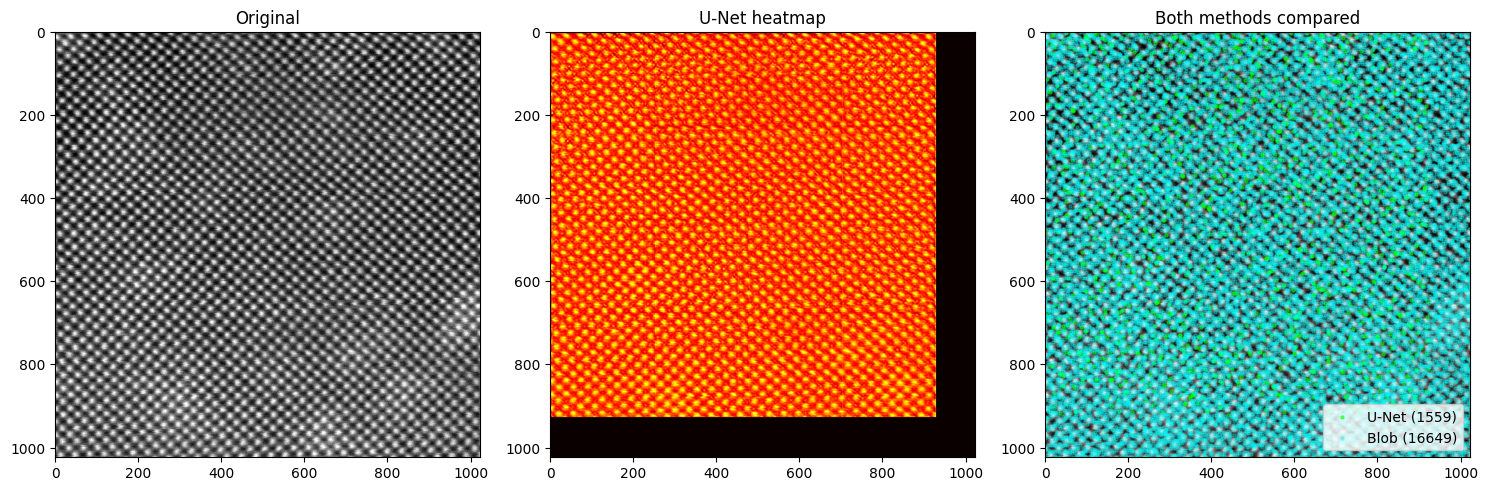

U-Net found 1559 atoms


In [ ]:
def predict_tiled(model, image, tile_size=256, overlap=32, device='cpu'):
    """Run the U-Net on a large image by tiling."""
    h, w = image.shape
    step = tile_size - overlap
    heatmap = np.zeros((h, w), dtype=np.float32)
    counts = np.zeros((h, w), dtype=np.float32)

    model.eval()
    with torch.no_grad():
        for y in range(0, h - tile_size + 1, step):
            for x in range(0, w - tile_size + 1, step):
                tile = image[y:y+tile_size, x:x+tile_size]
                inp = torch.tensor(tile[None, None, :, :], dtype=torch.float32).to(device)
                out = model(inp).cpu().numpy()[0, 0]
                heatmap[y:y+tile_size, x:x+tile_size] += out
                counts[y:y+tile_size, x:x+tile_size] += 1.0

    # Average overlapping regions
    counts = np.maximum(counts, 1.0)
    return heatmap / counts

real_heatmap = predict_tiled(model, real_image, tile_size=256, overlap=32, device=device)

# Extract atom positions
from scipy.ndimage import label, center_of_mass
binary = real_heatmap > 0.3
labeled, n = label(binary)
real_unet_positions = np.array(center_of_mass(binary, labeled, range(1, n + 1)))
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(real_image, cmap='gray')
axes[0].set_title('Original')

axes[1].imshow(real_heatmap, cmap='hot')
axes[1].set_title('U-Net heatmap')

axes[2].imshow(real_image, cmap='gray')
axes[2].scatter(real_unet_positions[:, 1], real_unet_positions[:, 0],
               c='lime', s=5, alpha=0.5, label=f'U-Net ({len(real_unet_positions)})')
axes[2].scatter(real_blobs[:, 1], real_blobs[:, 0],
               c='cyan', s=5, alpha=0.3, label=f'Blob ({len(real_blobs)})')
axes[2].legend()
axes[2].set_title('Both methods compared')

plt.tight_layout()
plt.show()

print(f"U-Net found {len(real_unet_positions)} atoms")

### Adjusting for real images

The U-Net was trained on simulated images that may not perfectly match your data. If results look poor, try:

- **Threshold**: Change `0.3` in the binary thresholding above. Lower catches more atoms, higher is more selective.
- **Retrain with matched parameters**: Go back to Part 4 and adjust `spacing`, `noise_level`, and `sigma` in `simulate_haadf` to better match your real image's atom spacing and noise level.
- **Image size**: If your image is very large (2048+), the tiling handles it, but you may want to crop a region of interest first.

## Part 9: Hackathon

The neural network you trained above was trained on low-noise images. Below is a noisy test image — your trained model will perform poorly on it.

**Your task:** Go back to Part 4 and adjust the training data parameters (especially `noise_level` range) to better match this test image, then retrain. Best F1 score wins.

Things you can change:
- `noise_level` range in the training loop in Part 4
- `n_train` (more training images)
- `epochs` in Part 5
- The threshold (`0.5`) in Part 6 when converting the heatmap to positions

---

Code cell 1 — challenge image and scoring:

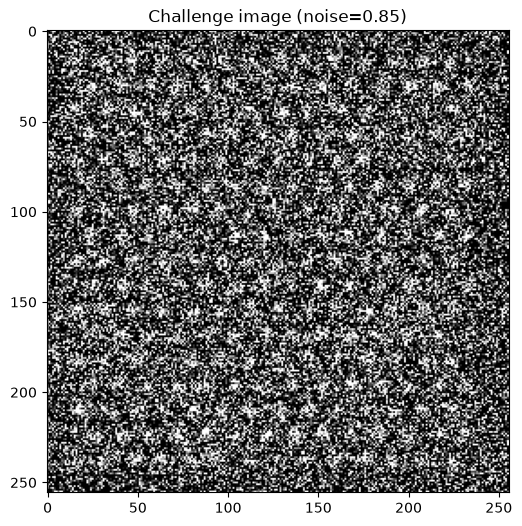

In [ ]:
# ---- DO NOT MODIFY THIS CELL ----
import hashlib
_rng = np.random.RandomState(int(hashlib.md5(b"hackathon2025").hexdigest()[:8], 16))

_ch_img = np.zeros((256, 256), dtype=np.float32)
_ch_atoms = []
row = 0
y = 16
while y < 240:
    x = 16 + (row % 2) * 8
    while x < 240:
        dx, dy = _rng.normal(0, 0.5, 2)
        ax, ay = x + dx, y + dy
        _ch_atoms.append([ax, ay])
        yy, xx = np.mgrid[0:256, 0:256]
        _ch_img += np.exp(-((xx - ax)**2 + (yy - ay)**2) / (2 * 2.5**2))
        x += 16
    y += 16 * np.sqrt(3) / 2
    row += 1
_ch_img /= _ch_img.max()
_ch_img += _rng.normal(0, 0.85, _ch_img.shape)
challenge_image = np.clip(_ch_img, 0, 1).astype(np.float32)
_truth = np.array(_ch_atoms)

def score(detected_positions):
    """Pass your Nx2 array of (y, x) positions. Returns F1 score."""
    from scipy.spatial import cKDTree
    if len(detected_positions) == 0:
        return 0.0
    detected = np.array(detected_positions)
    tree = cKDTree(_truth)
    distances, _ = tree.query(detected[:, ::-1])
    tp = (distances < 3.0).sum()
    p = tp / len(detected)
    r = tp / len(_truth)
    f1 = 2 * p * r / (p + r) if (p + r) > 0 else 0
    print(f"Precision: {p:.3f} | Recall: {r:.3f} | F1: {f1:.3f}")
    return f1

plt.figure(figsize=(6, 6))
plt.imshow(challenge_image, cmap='gray')
plt.title("Challenge image (noise=0.85)")
plt.show()

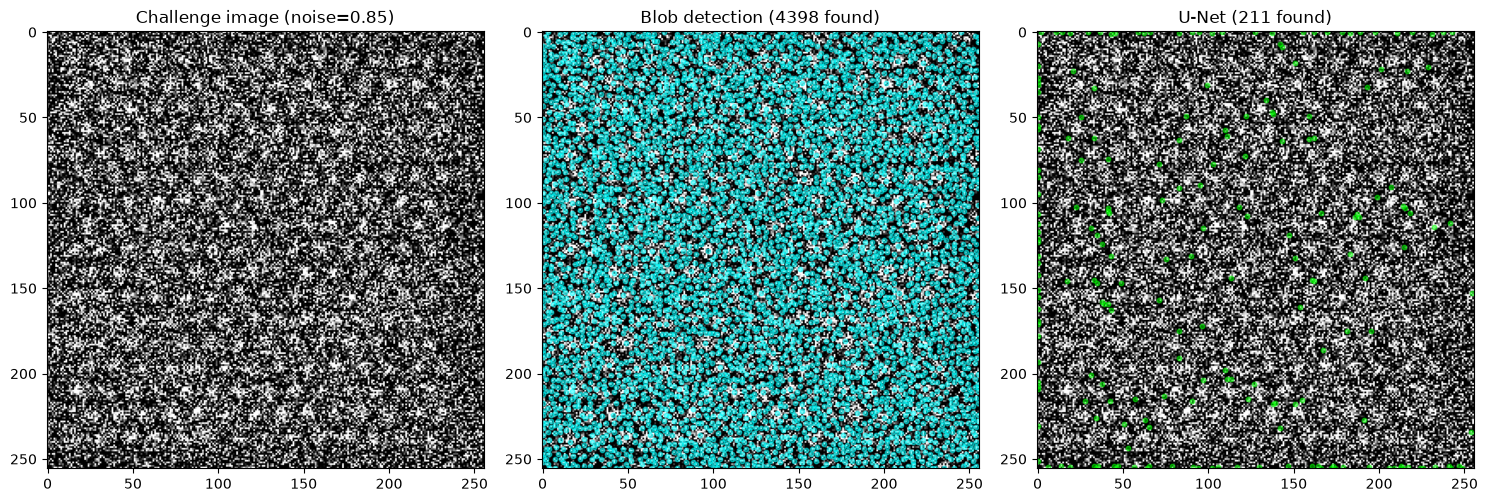

Blob detection:
Precision: 0.088 | Recall: 1.618 | F1: 0.166

U-Net (trained on clean images):
Precision: 0.005 | Recall: 0.004 | F1: 0.004
Found 211 atoms
Precision: 0.005 | Recall: 0.004 | F1: 0.004

Now go back to Part 4, adjust the noise range, etc, retrain, and try again!


In [ ]:
# ---- How do our existing methods perform on this? ----

# Blob detection

blobs = skimage.feature.blob_log(challenge_image, max_sigma=5, threshold=0.05)
blob_positions = blobs[:, :2]

# Current U-Net
model.eval()
with torch.no_grad():
    inp = torch.tensor(challenge_image[None, None, :, :], dtype=torch.float32).to(device)
    pred = model(inp).cpu().numpy()[0, 0]

binary = pred > 0.5
labeled, n = label(binary)
unet_positions = np.array(center_of_mass(binary, labeled, range(1, n + 1)))

# Show results
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(challenge_image, cmap='gray')
axes[0].set_title('Challenge image (noise=0.85)')

axes[1].imshow(challenge_image, cmap='gray')
axes[1].scatter(blob_positions[:, 1], blob_positions[:, 0], c='cyan', s=10, alpha=0.5)
axes[1].set_title(f'Blob detection ({len(blob_positions)} found)')

axes[2].imshow(challenge_image, cmap='gray')
if len(unet_positions) > 0:
    axes[2].scatter(unet_positions[:, 1], unet_positions[:, 0], c='lime', s=10, alpha=0.5)
axes[2].set_title(f'U-Net ({len(unet_positions)} found)')

plt.tight_layout()
plt.show()

print("Blob detection:")
score(blob_positions)
print("\nU-Net (trained on clean images):")
if len(unet_positions) > 0:
    _ = score(unet_positions)
else:
    print("No atoms detected")

# Run your current U-Net on the challenge image
model.eval()
with torch.no_grad():
    inp = torch.tensor(challenge_image[None, None, :, :], dtype=torch.float32).to(device)
    pred = model(inp).cpu().numpy()[0, 0]

binary = pred > 0.5
labeled, n = label(binary)
positions = np.array(center_of_mass(binary, labeled, range(1, n + 1)))

print(f"Found {len(positions)} atoms")
score(positions)
print("\nNow go back to Part 4, adjust the noise range, etc, retrain, and try again!")